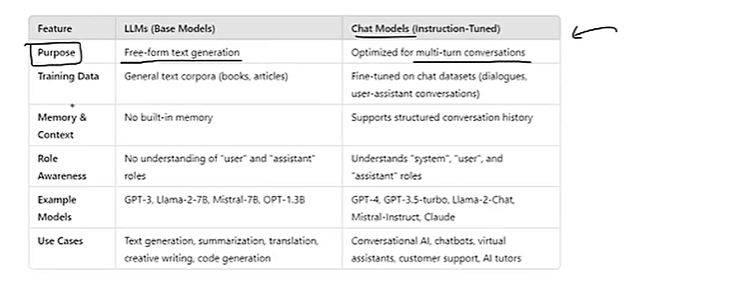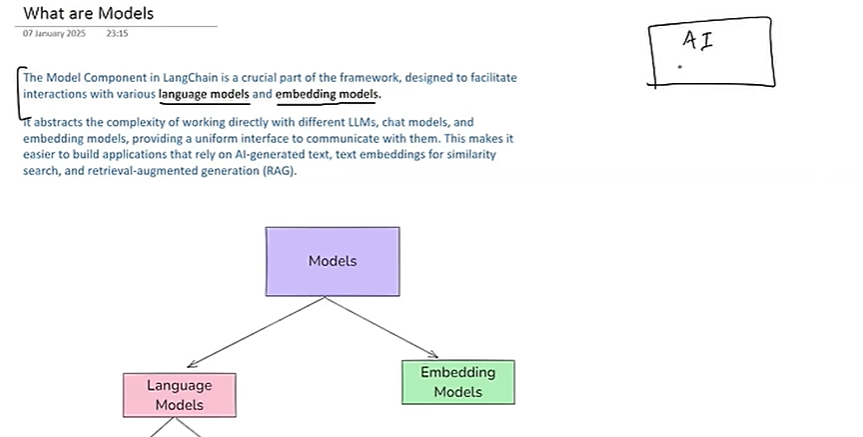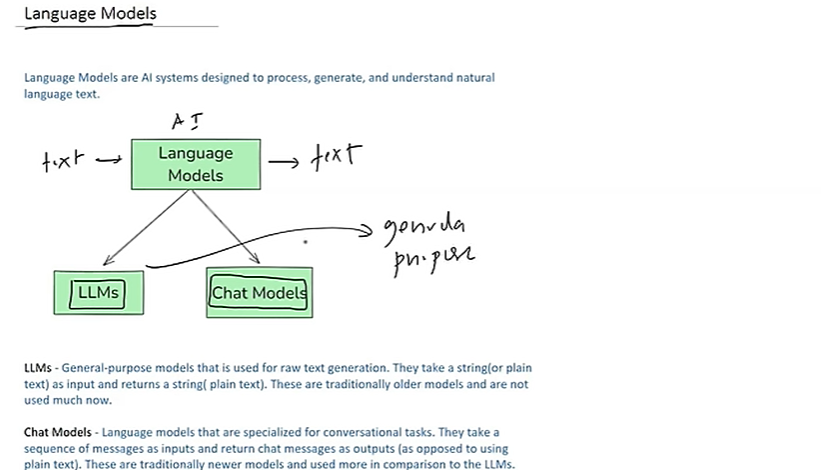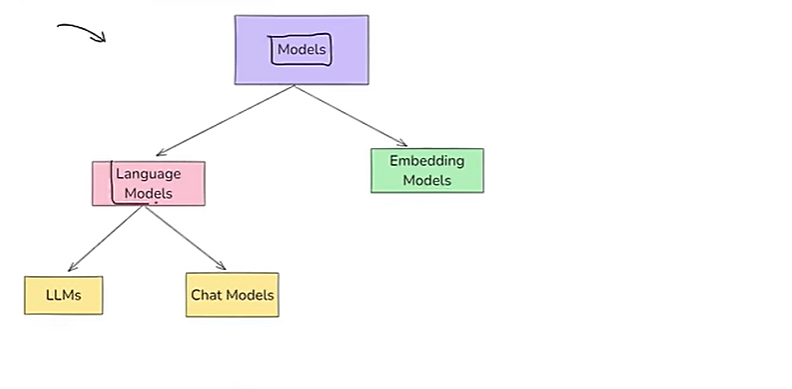

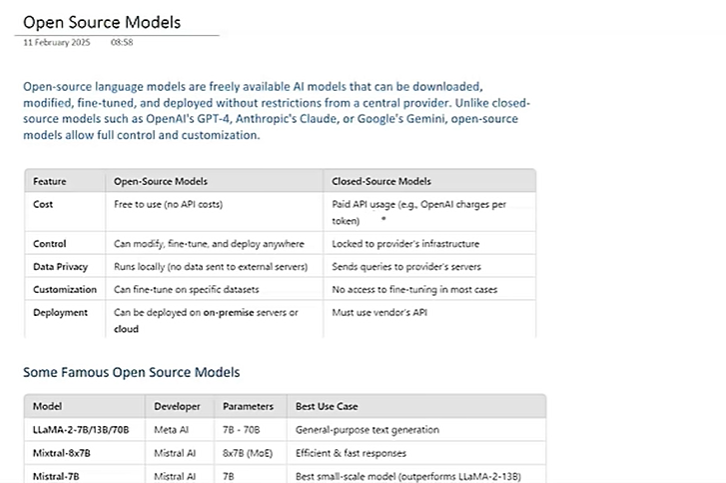

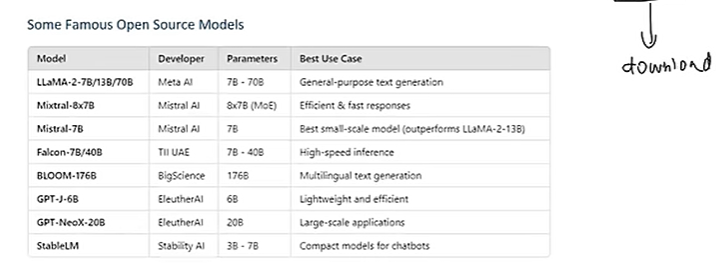

open source model where u dont have to pay for API Key Like OPEN AI ets - https://huggingface.co/models

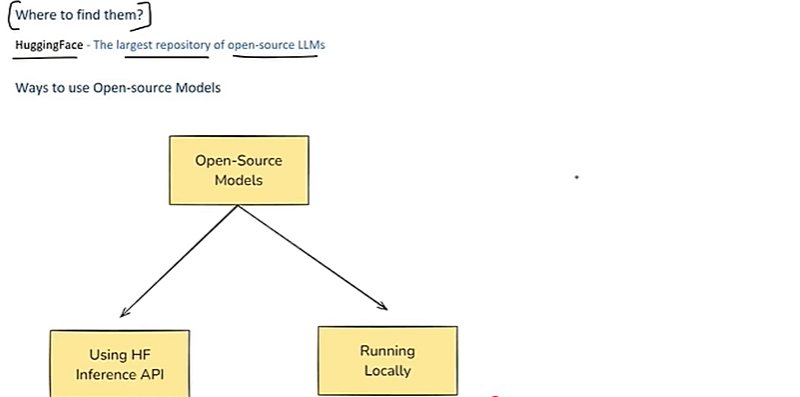

#HOW TO USE API KEY

## OPEN AI




In [ ]:
from langchain_openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

llm = OpenAI(model='gpt-3.5-turbo-instruct')

result = llm.invoke("What is the capital of India")

print(result)

## chat model

In [1]:
#open ai api for chat



In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI(model='gpt-4', temperature=1.5, max_completion_tokens=10)

result = model.invoke("Write a 5 line poem on cricket")

print(result.content)

In [ ]:
#antropic api for chat

from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv()

model = ChatAnthropic(model='claude-3-5-sonnet-20241022')

result = model.invoke('What is the capital of India')

print(result.content)

In [ ]:
#gemini


from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-1.5-pro')

result = model.invoke('What is the capital of India')

print(result.content)


## hugging face open source api of mode

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

result = model.invoke("What is the capital of India")

print(result.content)

another

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
import os

os.environ['HF_HOME'] = 'D:/huggingface_cache'

llm = HuggingFacePipeline.from_model_id(
    model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
    task='text-generation',
    pipeline_kwargs=dict(
        temperature=0.5,
        max_new_tokens=100
    )
)
model = ChatHuggingFace(llm=llm)

result = model.invoke("What is the capital of India")

print(result.content)

## Embedding model

In [ ]:
# open ai embedding


from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=32)

result = embedding.embed_query("Delhi is the capital of India")

print(str(result))

In [ ]:
# for document open ai

from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=32)

documents = [
    "Delhi is the capital of India",
    "Kolkata is the capital of West Bengal",
    "Paris is the capital of France"
]

result = embedding.embed_documents(documents)

print(str(result))

### document similarity - in 5 line if we asked in which page is related

In [ ]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=300)

documents = [
    "Virat Kohli is an Indian cricketer known for his aggressive batting and leadership.",
    "MS Dhoni is a former Indian captain famous for his calm demeanor and finishing skills.",
    "Sachin Tendulkar, also known as the 'God of Cricket', holds many batting records.",
    "Rohit Sharma is known for his elegant batting and record-breaking double centuries.",
    "Jasprit Bumrah is an Indian fast bowler known for his unorthodox action and yorkers."
]

query = 'tell me about bumrah'

doc_embeddings = embedding.embed_documents(documents)
query_embedding = embedding.embed_query(query)

scores = cosine_similarity([query_embedding], doc_embeddings)[0]

index, score = sorted(list(enumerate(scores)),key=lambda x:x[1])[-1]

print(query)
print(documents[index])
print("similarity score is:", score)



